# HAGRID YOLOv5 Live Demo

A compact notebook for model loading, single-image inference, batch inference, and result visualization.


## 1. 環境初始化 (Environment Setup)

Run this cell first. On Colab, it downloads the shared demo package, installs dependencies, and verifies required paths.


In [ ]:
%%capture setup_log
import os
import subprocess
import sys
from pathlib import Path

FOLDER_URL = "https://drive.google.com/drive/folders/19J9mf99svPelodM0Xuvs7OrChEzmyPqu?usp=sharing"
DEMO_DIR = Path("/content/hagrid_yolov5_demo")
SHARED_DIR = Path("/content/hagrid_yolov5_shared")
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules

if IN_COLAB and not (DEMO_DIR / "gesture_inference_analysis.ipynb").exists():
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    subprocess.check_call(["rm", "-rf", str(SHARED_DIR)])
    SHARED_DIR.mkdir(parents=True, exist_ok=True)
    subprocess.check_call([sys.executable, "-m", "gdown", "--folder", FOLDER_URL, "-O", str(SHARED_DIR)])
    zip_path = sorted(SHARED_DIR.rglob("hagrid_yolov5_demo.zip"))[0]
    subprocess.check_call(["rm", "-rf", str(DEMO_DIR)])
    subprocess.check_call(["unzip", "-q", str(zip_path), "-d", "/content"])

if IN_COLAB:
    os.chdir(DEMO_DIR)

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from demo.demo_bootstrap import setup_colab_demo
ROOT = setup_colab_demo(FOLDER_URL)
os.chdir(ROOT)

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Repo root: {ROOT}")
!python colab_check_paths.py

Repo root: C:\Users\alana\Downloads\hagrid_120k\yolo\hagrid_yolov5_demo
Repo root: C:\Users\alana\Downloads\hagrid_120k\yolo\hagrid_yolov5_demo
notebook           exists=True  C:\Users\alana\Downloads\hagrid_120k\yolo\hagrid_yolov5_demo\gesture_inference_analysis.ipynb
env_toml           exists=True  C:\Users\alana\Downloads\hagrid_120k\yolo\hagrid_yolov5_demo\colab_env.toml
bootstrap          exists=True  C:\Users\alana\Downloads\hagrid_120k\yolo\hagrid_yolov5_demo\demo\demo_bootstrap.py
demo_utils         exists=True  C:\Users\alana\Downloads\hagrid_120k\yolo\hagrid_yolov5_demo\demo\demo_utils.py
data_yaml          exists=True  C:\Users\alana\Downloads\hagrid_120k\yolo\hagrid_yolov5_demo\datasets\HAGRID-YOLO\data.yaml
batch_images       exists=True  C:\Users\alana\Downloads\hagrid_120k\yolo\hagrid_yolov5_demo\datasets\HAGRID-YOLO\test\images | images=800
single_demo_images exists=True  C:\Users\alana\Downloads\hagrid_120k\yolo\hagrid_yolov5_demo\assets\inference_images | images=32
cu

## 2. 訓練資料分布 (Dataset Distribution)


,split,images,labels,image_ratio,image_ratio_pct
0,Train,6000,6000,0.789474,78.95
1,Validation,800,800,0.105263,10.53
2,Test,800,800,0.105263,10.53


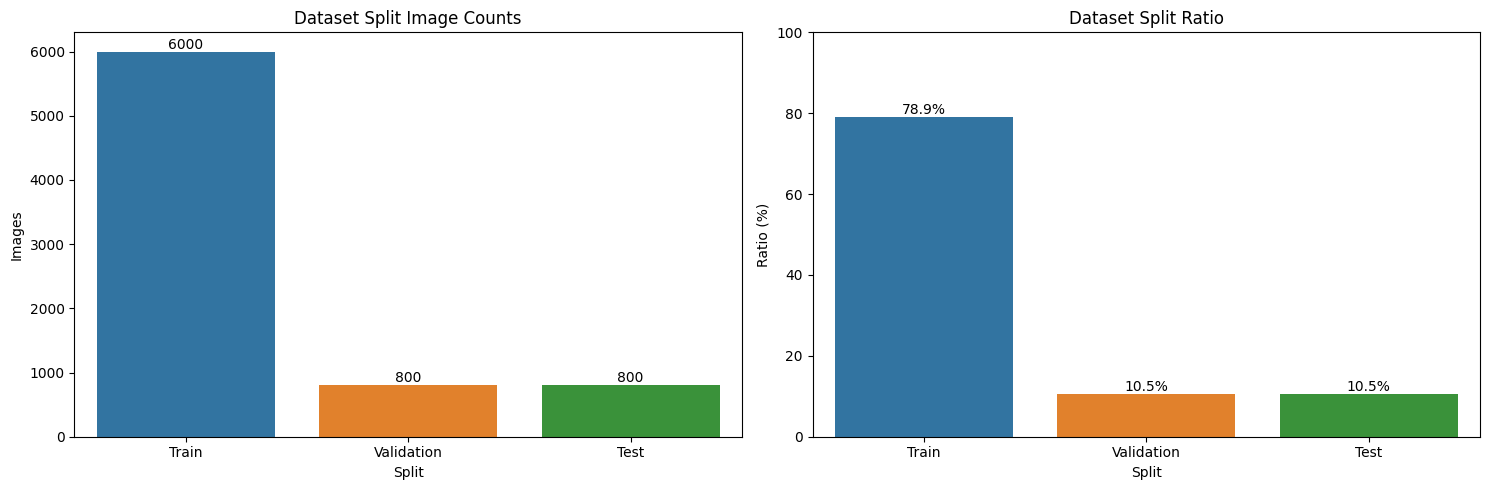

split,Test,Train,Validation
class_name,,,
like,200,1500,200
nogesture,203,1355,193
ok,200,1500,200
peace,200,1500,200
stop,200,1500,200


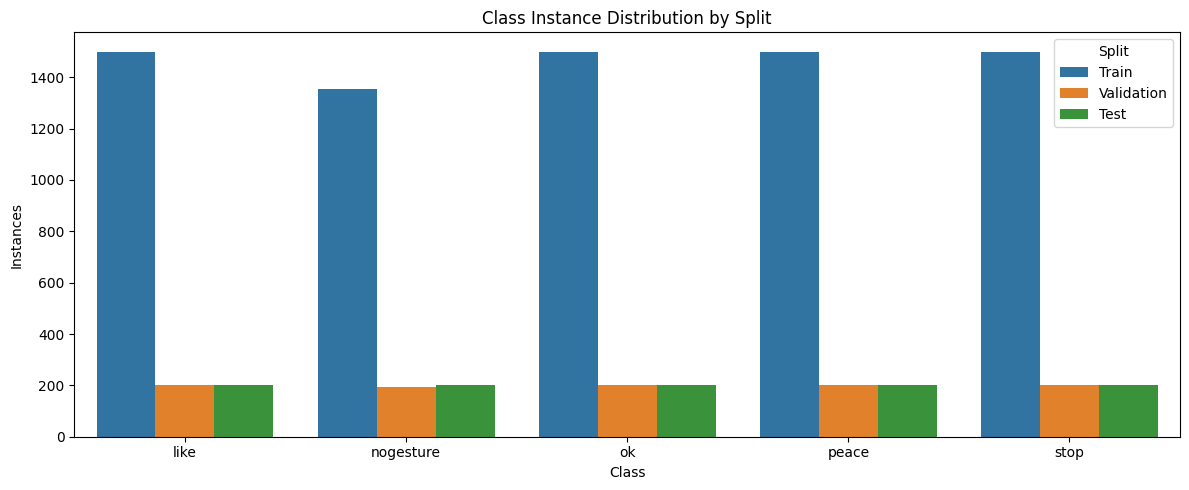

In [2]:
from demo.demo_utils import load_demo_config, load_dataset_distribution, show_dataset_distribution

config = load_demo_config(ROOT)
dataset_split_df, class_distribution_df = load_dataset_distribution(config)

show_dataset_distribution(dataset_split_df, class_distribution_df)


## 3. 載入訓練模型 (Model Loading)

Load the trained YOLOv5s model and set the inference thresholds.


In [3]:
from demo.demo_utils import load_demo_config, load_model, list_images

config = load_demo_config(ROOT)
config["conf_thres"] = 0.50
config["iou_thres"] = 0.45

runtime = load_model(config)

print(f"Device: {runtime['device']}")
print(f"Weights: {config['weights']}")
print(f"Classes: {runtime['names']}")

YOLOv5  2026-4-25 Python-3.9.0 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3080, 10240MiB)

Fusing layers... 
Model summary: 157 layers, 7023610 parameters, 0 gradients, 15.8 GFLOPs


Device: cuda:0
Weights: C:\Users\alana\Downloads\hagrid_120k\yolo\hagrid_yolov5_demo\artifacts\runs\train\exp_batchsize_32\weights\best.pt
Classes: {0: 'like', 1: 'nogesture', 2: 'ok', 3: 'peace', 4: 'stop'}


## 4. 即時影像推論 (Inference)

Use the curated set for a stable live demo. Change `SINGLE_IMAGE_PATH` or `BATCH_IMAGE_DIR` when testing custom images.


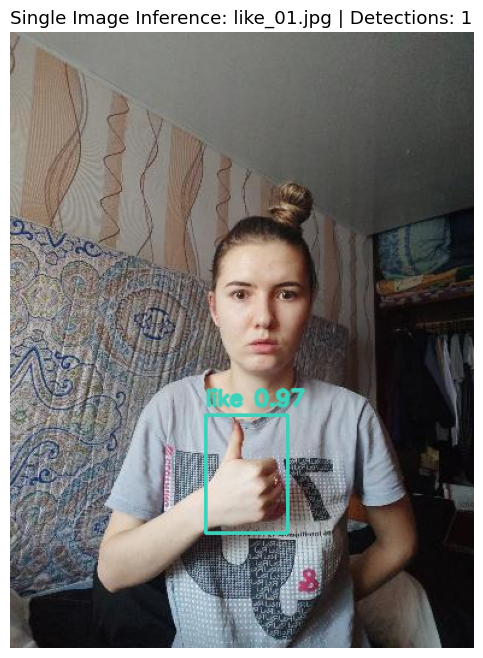

,image_name,width,height,num_detections,read_ms,preprocess_ms,inference_ms,postprocess_ms,annotate_ms,total_ms
0,like_01.jpg,385,512,1,1.773,1.14,67.04,59.407,0.656,130.02


,xyxy,confidence,class_id,class_name
0,"[162.0, 318.0, 230.0, 416.0]",0.967203,0,like


In [4]:
from pathlib import Path
import pandas as pd
from demo.demo_utils import predict, predict_folder, show_single_result, timing_record

SINGLE_IMAGE_PATH = next(iter(list_images(config["curated_dir"])))

single_result = predict(SINGLE_IMAGE_PATH, runtime, config)
single_timing = pd.DataFrame([timing_record(single_result)]).round(3)

show_single_result(single_result)
display(single_timing)
display(pd.DataFrame(single_result["detections"]))

,image_name,width,height,num_detections,read_ms,preprocess_ms,inference_ms,postprocess_ms,annotate_ms,total_ms
0,like_01.jpg,385,512,1,1.548,0.696,5.976,2.767,0.600,11.589
1,like_02.jpg,384,512,1,1.385,0.775,75.004,1.401,0.620,79.187
2,nogesture_01.jpg,512,384,2,1.522,0.539,66.115,2.435,0.760,71.373
3,nogesture_02.jpg,230,512,2,0.889,0.412,72.937,1.224,0.708,76.172
4,ok_01.jpg,384,512,1,1.437,0.688,5.976,1.647,0.569,10.319
5,ok_02.jpg,384,512,1,1.363,0.649,5.020,1.495,0.479,9.008
6,peace_01.jpg,384,512,1,1.295,0.521,5.349,1.434,0.510,9.111
7,peace_02.jpg,384,512,1,1.261,0.513,5.176,1.664,0.528,9.143
8,stop_01.jpg,384,512,1,1.259,0.535,5.435,1.451,0.513,9.197
9,stop_02.jpg,384,512,1,1.250,0.507,5.539,1.446,0.499,9.244


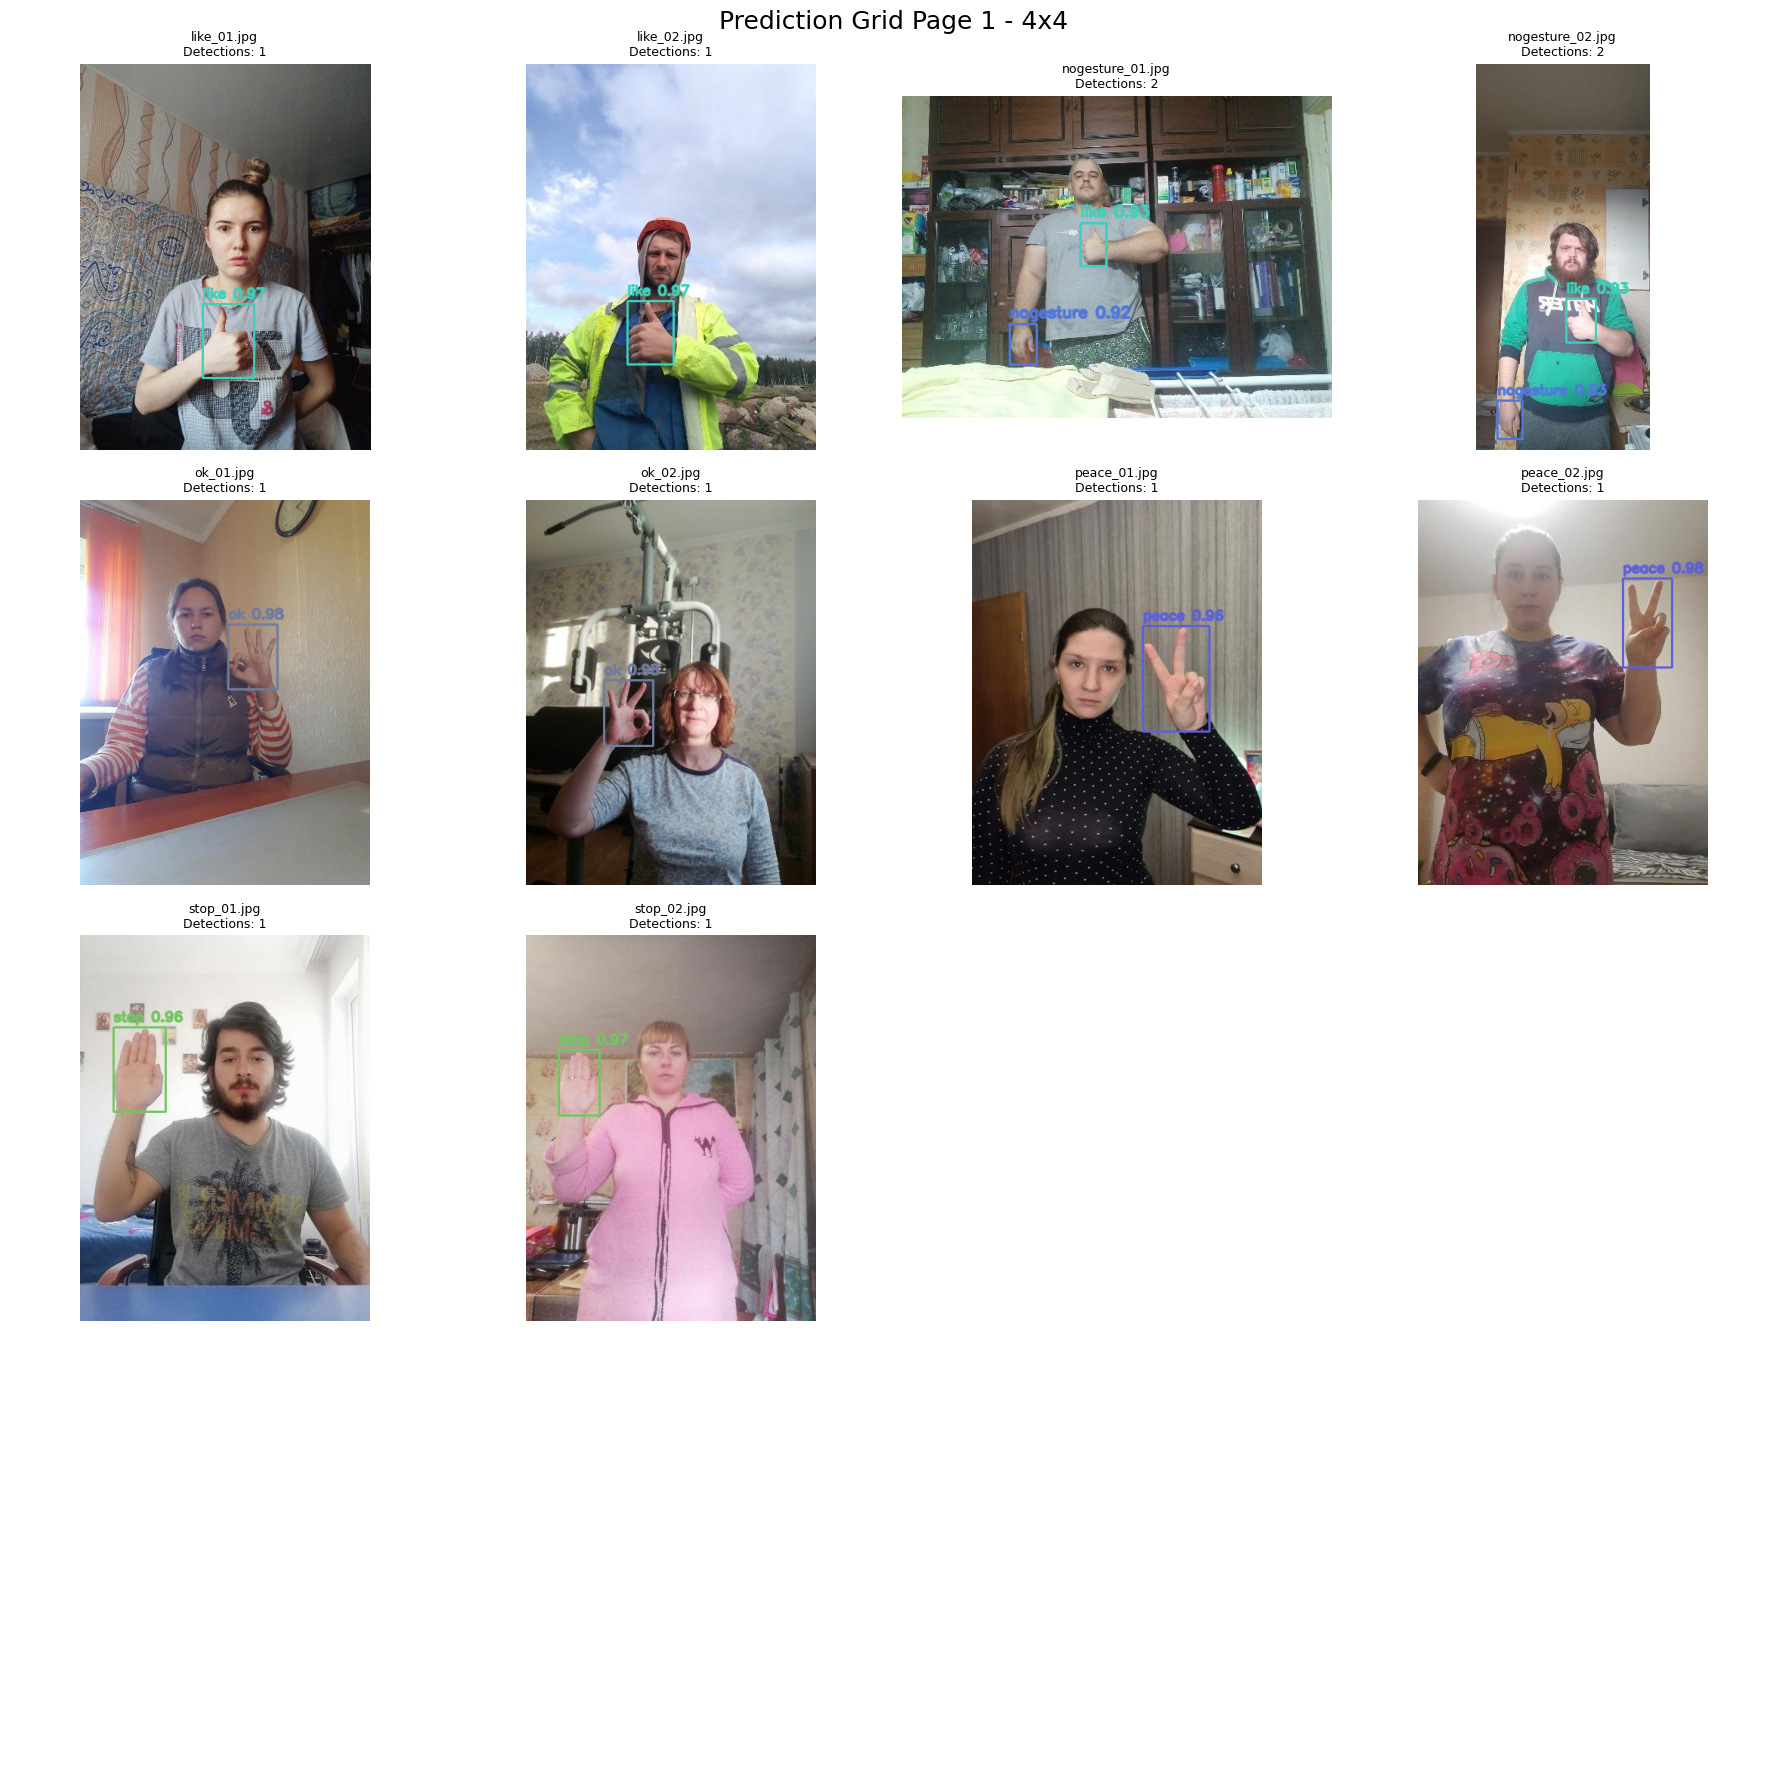

In [5]:
from demo.demo_utils import show_prediction_grid

BATCH_IMAGE_DIR = config["curated_dir"]

inference_results, inference_df = predict_folder(BATCH_IMAGE_DIR, runtime, config)

display(inference_df.round(3))
show_prediction_grid(inference_results)

### 推論結果觀察

這組精選測試集主要用來展示模型在 live demo 情境下的穩定推論能力。從結果可以觀察到，多數圖片都能輸出單一且高信心度的手勢偵測框，代表模型不只判斷圖片中是否有手勢，也能定位手勢在畫面中的位置。

若同一張圖片出現多個 bounding boxes，這是 object detection 任務的合理現象，表示模型在同一張影像中找到多個候選手部或手勢區域；它不同於 image classification，不會被限制只能輸出一個類別。現場說明時可以強調：本模型輸出的資訊包含「類別、位置、信心分數」，因此比單純分類更適合應用在視訊畫面或互動介面中。

Confidence 分數代表模型對該偵測框的信心程度。若現場使用面試官提供的圖片且偵測結果偏少，可以嘗試降低 `conf_thres`，例如從 `0.50` 調整到 `0.30`；如果畫面出現太多低品質偵測框，則可以提高信心門檻。


## 5. 結果視覺化 (Visualization)

Summarize latency, compare training runs, and present the model's experiment results.


,mean,median,min,max,p95,fps_from_mean
read_ms,1.321,1.329,0.889,1.548,1.536,757.180
preprocess_ms,0.584,0.537,0.412,0.775,0.739,1713.737
inference_ms,25.253,5.757,5.020,75.004,74.074,39.600
postprocess_ms,1.696,1.473,1.224,2.767,2.617,589.491
annotate_ms,0.579,0.548,0.479,0.760,0.736,1728.340
total_ms,29.434,9.781,9.008,79.187,77.830,33.974


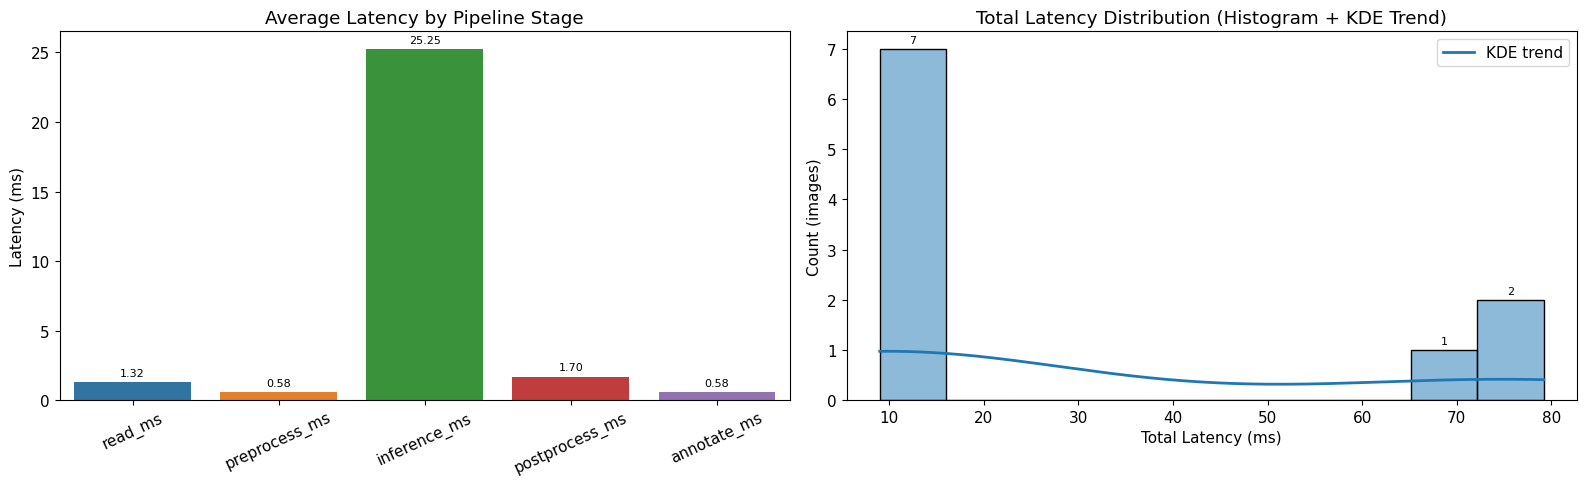

In [6]:
from demo.demo_utils import show_latency_summary

latency_summary = show_latency_summary(inference_df)

,run,experiment_group,experiment_label,experiment_value,lr0,...,recall,mAP50,mAP50_95,last_train_box_loss,last_val_box_loss
0,exp_batchsize_16,Batch Size,Batch 16,16.000,0.010,...,0.97436,0.98737,0.80192,0.015273,0.014707
1,exp_batchsize_32,Batch Size,Batch 32,32.000,0.010,...,0.98097,0.99005,0.80349,0.015334,0.014536
2,exp_batchsize_64,Batch Size,Batch 64,64.000,0.010,...,0.97502,0.98887,0.80288,0.015167,0.014890
3,exp_lr_0p003,Learning Rate,LR 0.003,0.003,0.003,...,0.96627,0.98705,0.78447,0.016715,0.015619
4,exp_lr_0p01,Learning Rate,LR 0.01,0.010,0.010,...,0.98097,0.99005,0.80349,0.015334,0.014536
5,exp_lr_0p03,Learning Rate,LR 0.03,0.030,0.030,...,0.98027,0.98733,0.79651,0.016225,0.015246


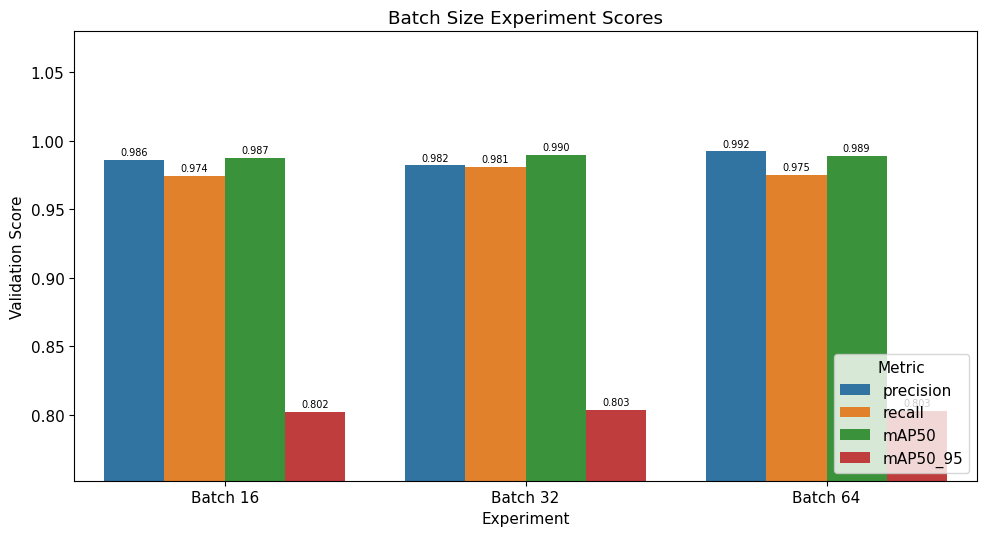

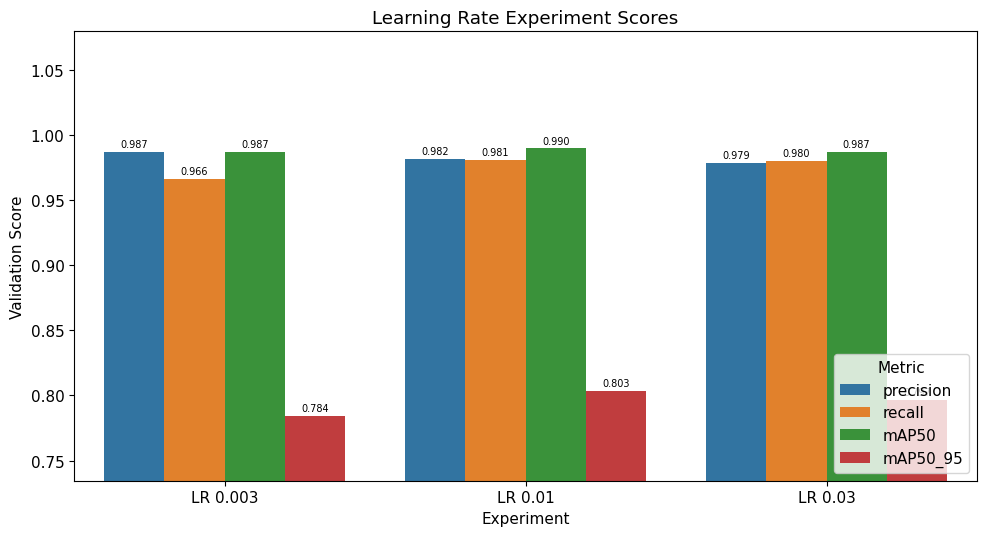

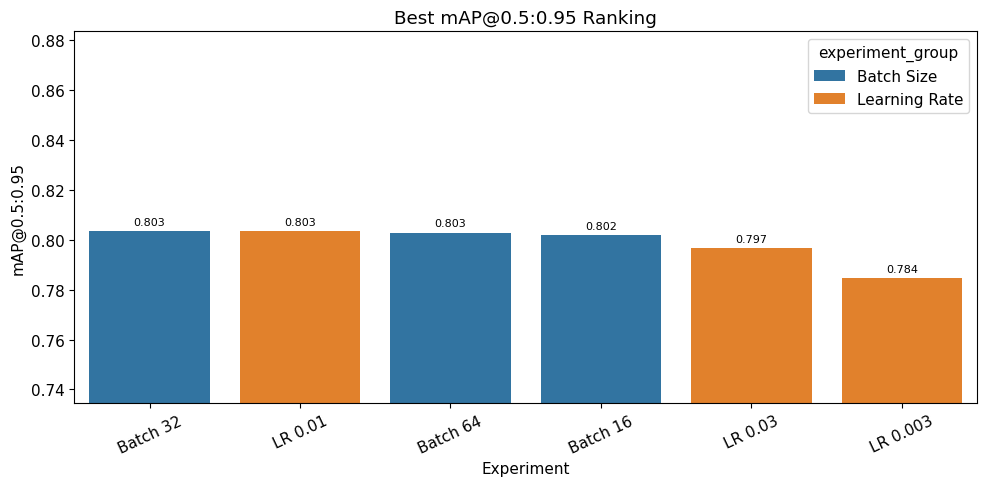

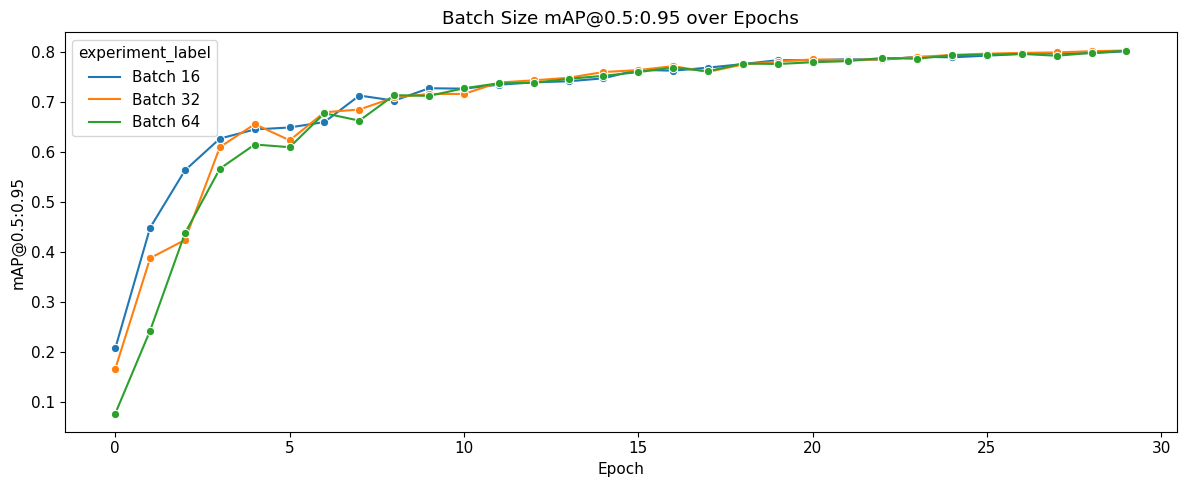

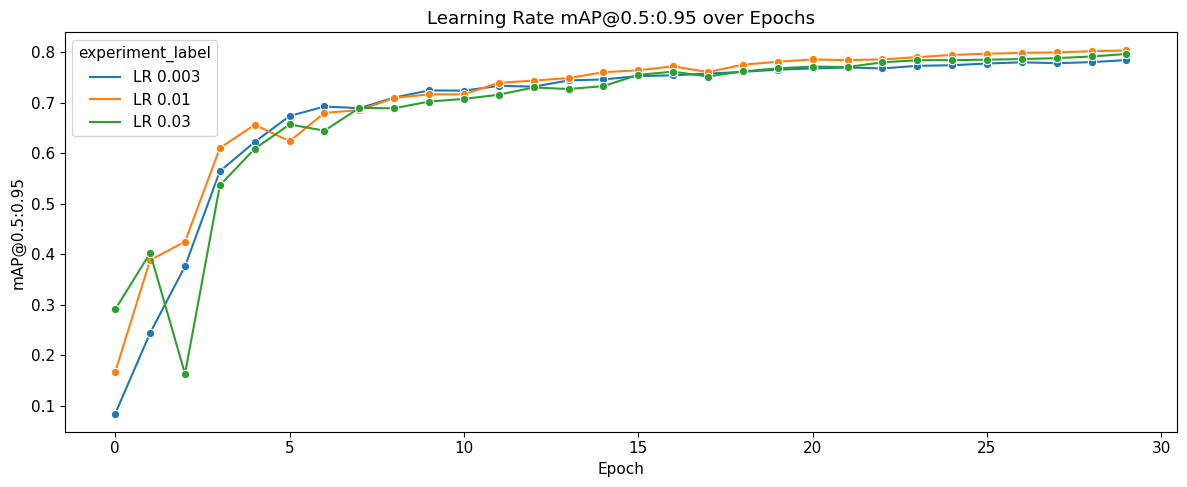

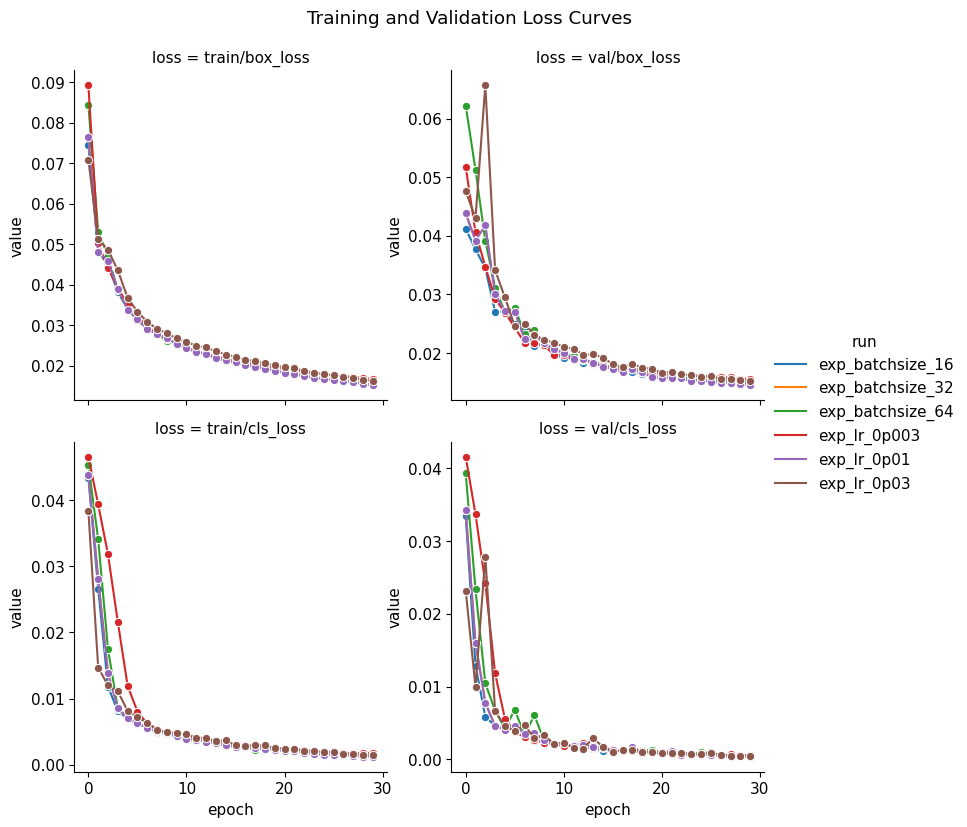

In [7]:
from demo.demo_utils import load_runs, show_run_comparison

runs_df, curves_df = load_runs(ROOT)
show_run_comparison(runs_df, curves_df)